In [1]:
from utils import * 
import networkx as nx
import matplotlib.pyplot as plt
import random

In [4]:
n = 3
G1 = nx.DiGraph()
G2 = nx.DiGraph()
V = range(1,n+1)
G1.add_nodes_from(V)
G2.add_nodes_from(V)
E1 = [(1,2),(2,3)]
B1 = [(2,3)]
E2 = [(1,2),(1,3)]
B2 = [(2,3)]
G1.add_edges_from(E1)
G2.add_edges_from(E2)

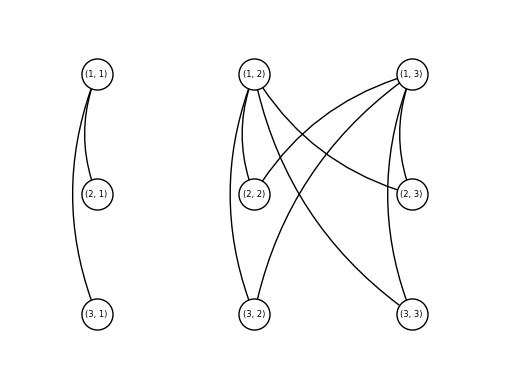

In [5]:
IG = induced_graph(V,B1,B2)
plot_induced(IG)

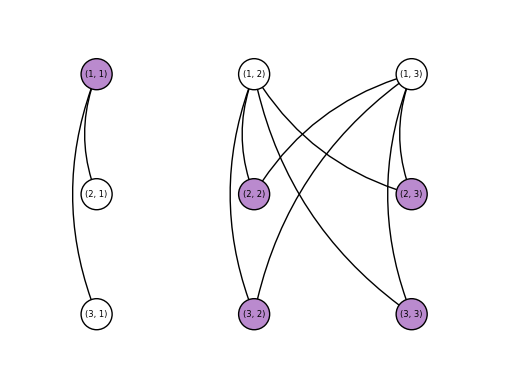

In [9]:
V = list(G1.nodes())
V.sort()
IG = induced_graph(V, B1, B2)
covers = [(1,1),(2,2),(2,3),(3,2),(3,3)]
node_colors = [
"#ba8ace" if node in covers else
"white"
for node in IG.nodes()
]
options = {
"font_size": 6,
"node_size": 500,
"node_color": node_colors,
"edgecolors": "black",
"linewidths": 1,
"width": 1,
}
pos = {(i, j): (j, i) for i, j in IG.nodes()}
nx.draw_networkx(IG, pos, arrows=True, **options, connectionstyle="arc3,rad=0.2")
plt.gca().invert_yaxis()
ax = plt.gca()
ax.margins(0.20)
ax.set_axis_off()
plt.show()

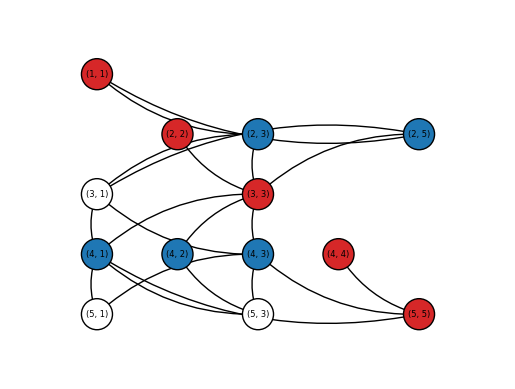

True

In [375]:
num_vertex = 5
num_confounding = 6
G1 = random_dag(num_vertex,random.random())
B1 = random_confounding(num_vertex,num_confounding)
G2 = random_dag(num_vertex,random.random())
B2 = random_confounding(num_vertex,num_confounding)
plot_auxiliary(G1,G2,B1,B2)

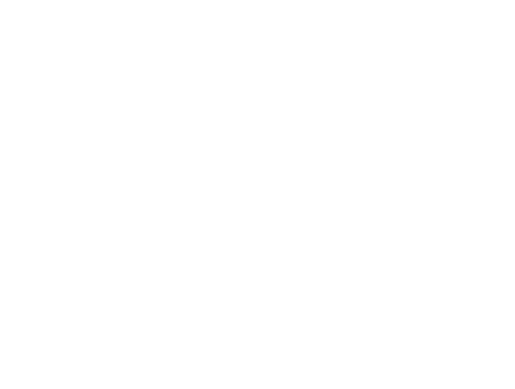

In [376]:
plot_reduced(G1,G2,B1,B2)

In [286]:
V = list(G1.nodes())
V.sort()
IG = induced_graph(V, B1, B2)
IG_cleaned = IG_clean_up(IG, G1, G2, B2)
unremovable = get_removable(V, G1, G2, B2)[1] & IG_cleaned.nodes
unremovable_neighbors = neighbors_of_set(IG_cleaned, unremovable)

remain = IG_cleaned.nodes - unremovable - unremovable_neighbors
IG_remain = IG_cleaned.subgraph(remain).copy()
IG_remain.remove_nodes_from(list(nx.isolates(IG_remain)))

for cover in minimal_vertex_covers_fast(IG_remain):
    print (cover)

{(1, 2), (2, 1), (1, 5), (3, 1), (1, 4), (2, 3), (3, 3), (2, 2), (3, 2), (1, 3)}
{(1, 2), (2, 1), (3, 1), (1, 4), (2, 3), (3, 3), (2, 2), (3, 2), (2, 5), (3, 5)}
{(1, 2), (2, 1), (1, 5), (3, 1), (1, 1), (1, 4), (2, 3), (3, 3), (2, 5), (3, 5)}
{(1, 2), (1, 5), (1, 1), (1, 4), (1, 3)}
{(1, 2), (1, 1), (1, 4), (2, 3), (3, 3), (2, 2), (3, 2), (2, 5), (1, 3), (3, 5)}
{(2, 4), (2, 1), (3, 4), (1, 5), (3, 1), (1, 1), (2, 2), (3, 2), (2, 5), (1, 3), (3, 5)}
{(2, 4), (2, 1), (3, 4), (3, 1), (2, 3), (3, 3), (2, 2), (3, 2), (2, 5), (3, 5)}
{(2, 4), (1, 2), (2, 1), (3, 4), (1, 5), (3, 1), (2, 3), (3, 3), (2, 2), (3, 2), (1, 3)}
{(2, 4), (1, 2), (3, 4), (1, 5), (1, 1), (2, 2), (3, 2), (1, 3)}
{(2, 4), (1, 2), (3, 4), (1, 1), (2, 3), (3, 3), (2, 2), (3, 2), (2, 5), (1, 3), (3, 5)}


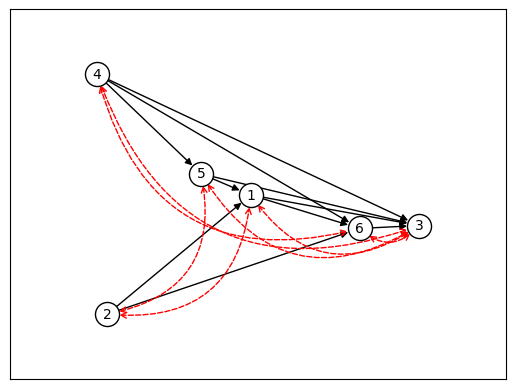

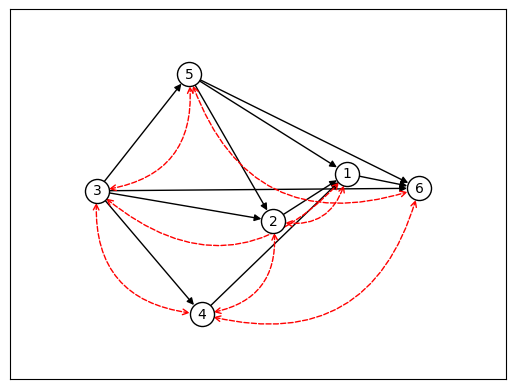

In [37]:
plot_admg(G1,B1)
plot_admg(G2,B2)